# Movie Review Sentiment Analysis

## Notebook 01: Exploratory Data Analysis

In this notebook, we explore the IMDB movie review dataset and understand the sentiment distribution, review length, and common words.

In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from utils import load_data

In [5]:
df = load_data("../data/imdb_reviews.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [8]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [9]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

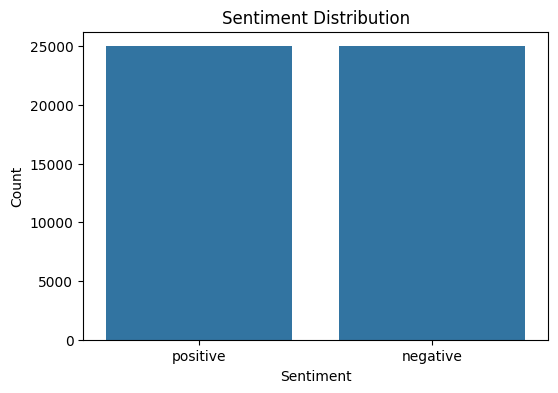

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [11]:
df["review_length"] = df["review"].apply(len)
df[["review", "review_length", "sentiment"]].head()

,review,review_length,sentiment
0,One of the other reviewers has mentioned that ...,1761,positive
1,A wonderful little production. <br /><br />The...,998,positive
2,I thought this was a wonderful way to spend ti...,926,positive
3,Basically there's a family where a little boy ...,748,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",1317,positive


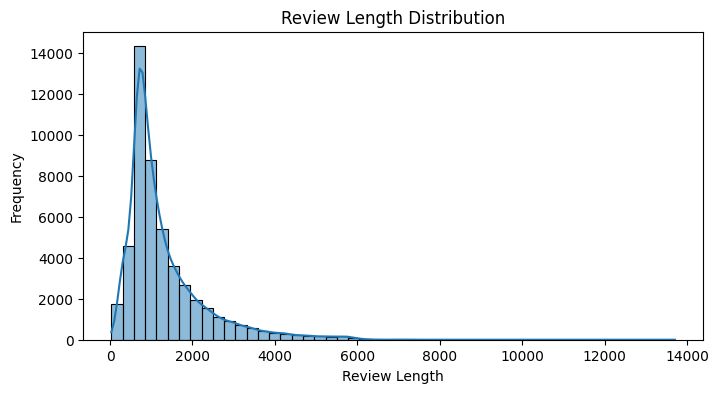

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df["review_length"], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()

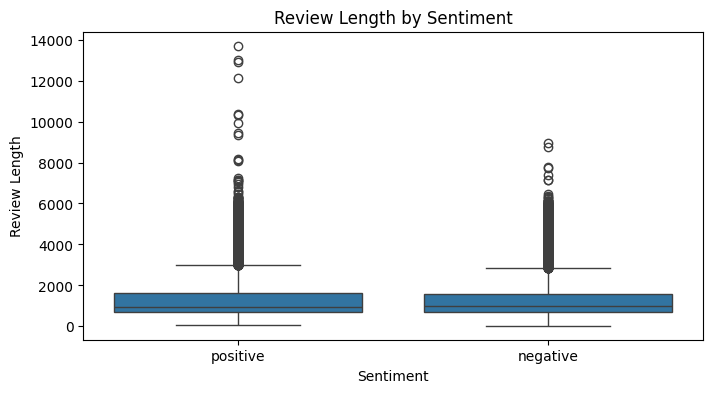

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="sentiment", y="review_length")
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")
plt.show()

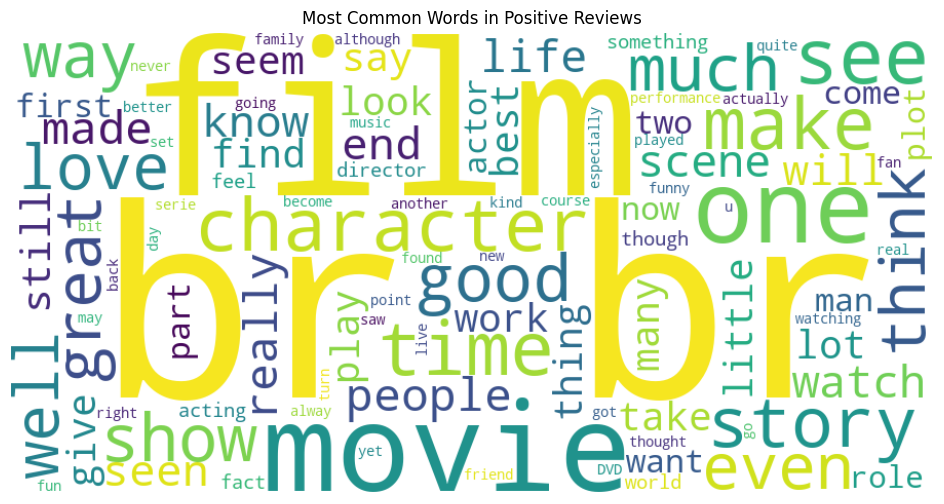

In [14]:
positive_text = " ".join(df[df["sentiment"] == "positive"]["review"].astype(str))

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Positive Reviews")
plt.show()

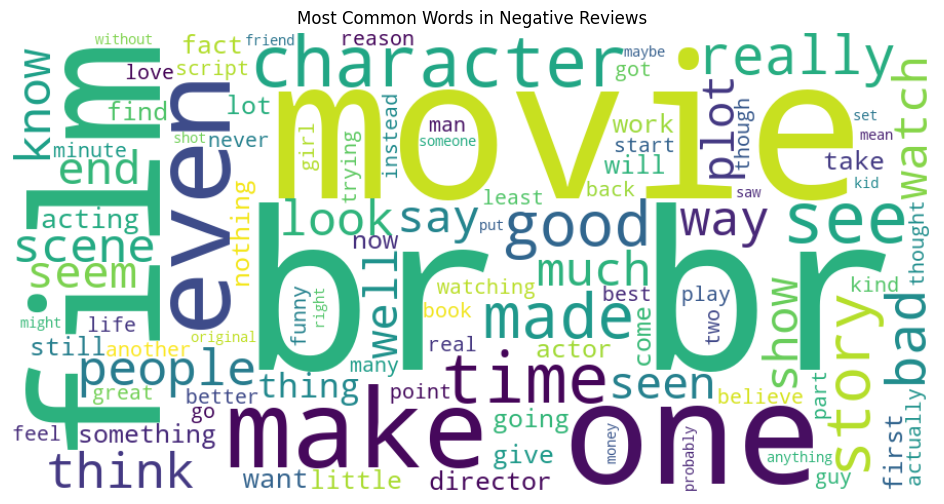

In [15]:
negative_text = " ".join(df[df["sentiment"] == "negative"]["review"].astype(str))

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()

## EDA Summary

- The dataset contains movie reviews and sentiment labels.
- The target column is `sentiment`.
- Sentiment has two classes: positive and negative.
- The dataset is balanced.
- Reviews have different lengths.
- Reviews contain unnecessary text such as HTML tags.
- Therefore, text cleaning is required before model training.